In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Read the file tokens_clean.txt and store the cleaned captions in a dictionary
import json

content = None

with open ("drive/MyDrive/image-caption-generator/TextFiles/tokens_clean.txt", 'r') as file:
    content = file.read()

json_acceptable_string = content.replace("'", "\"")
content = json.loads(json_acceptable_string)

In [4]:
print(type(content))

<class 'dict'>


In [5]:
#Iterate over the captions word by word, and append each word to total_words
total_words = []

for key in content.keys():
    for caption in content[key]:
        for i in caption.split():
            total_words.append(i)

print("Total Words = %d" %len(total_words))

Total Words = 1955246


In [6]:
# Compute the frequency of occurrence of each word, and store it in a dictionary of word-freq
import collections

counter = collections.Counter(total_words)
freq_cnt = dict(counter)

print("Number of unique words = " + str(len(freq_cnt.keys())))

Number of unique words = 18079


In [7]:
# Store the word-freq pairs (from the dictionary freq_cnt) in a list, sorted in decreasing order of frequency
sorted_freq_cnt = sorted(freq_cnt.items(), reverse=True, key=lambda x:x[1])

In [8]:
threshold = 10

#Filter off those words whose frequency of occurrence in less than threshold
sorted_freq_cnt = [x for x in sorted_freq_cnt if x[1]>threshold]
# Store these common words in total_words
total_words = [x[0] for x in sorted_freq_cnt]

print("Number of common unique words = " + str(len(total_words)))

Number of common unique words = 5136


PREPARE TRAIN AND TEST DATA

In [9]:
# Read training and testing image names

train_file_data = ""
test_file_data = ""

with open ("drive/MyDrive/image-caption-generator/TextFiles/flickr30k_train.txt", 'r') as file:
    train_file_data = file.read()

with open ("drive/MyDrive/image-caption-generator/TextFiles/flickr30k_test.txt", 'r') as file:
    test_file_data = file.read()

In [10]:
# Obtain a list of train and test images
train_data = [img_file_name for img_file_name in train_file_data.split("\n")[:-1]]
test_data = [img_file_name for img_file_name in test_file_data.split("\n")[:-1]]

# Obtain image ID from image file name
train_data = [image.split(".")[0] for image in train_data]
test_data = [image.split(".")[0] for image in test_data]

In [11]:
train_data[:5]

['1000092795', '10002456', '1000268201', '1000344755', '1000366164']

In [12]:
# For each imageID in train_data, store its captions in a dictionary

train_content = {}

for imageID in train_data:
    train_content[imageID] = []
    for caption in content[imageID]:
        # Add a start sequence token in the beginning and an end sequence token at the end
        cap_to_append = "startseq " + caption + " endseq"
        train_content[imageID].append(cap_to_append)

In [13]:
train_content['1001896054']

['startseq a man with reflective safety clothes and ear protection drives a john deere tractor on a road  endseq',
 'startseq john deere tractors cruises down a street while the driver wears easy to see clothing  endseq',
 'startseq a man in a neon green and orange uniform is driving on a green tractor  endseq',
 'startseq a man in a tractor wearing headphones driving down a paved street  endseq',
 'startseq a man driving a john deere tractor on a main road in the country  endseq']

EXTRACT FEATURES FROM IMAGES USING RESNET50 ARCHIECTURE

In [14]:
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

model = ResNet50(weights = 'imagenet', input_shape = (224, 224, 3))

In [15]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
from keras.models import Model
model_new = Model (model.input, model.layers[-2].output)

In [17]:
from keras.preprocessing import image
import numpy as np

def preprocess_image (img):
    img = image.load_img(img, target_size=(224, 224))
    img = image.img_to_array(img)

    # Convert 3D tensor to a 4D tendor
    img = np.expand_dims(img, axis=0)

    #Normalize image accoring to ResNet50 requirement
    img = preprocess_input(img)

    return img

(1, 224, 224, 3)


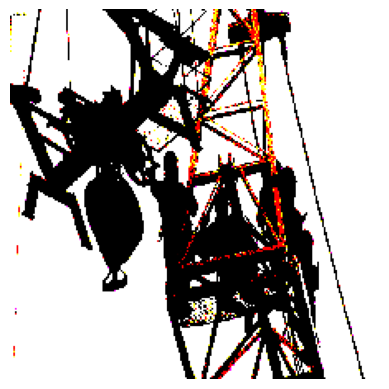

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

img = preprocess_image("drive/MyDrive/image-caption-generator/flickr30k_images/10002456.jpg")
print(img.shape)
plt.imshow(img[0])
plt.axis('off')
plt.show()

In [19]:
# A wrapper function, which inputs an image and returns its encoding (feature vector)
def encode_image (img):
    img = preprocess_image(img)
    feature_vector = model_new.predict(img)

    feature_vector = feature_vector.reshape((-1,))
    return feature_vector

In [23]:
from time import time
import numpy as np # Ensure numpy is imported
from tqdm.notebook import tqdm # Import tqdm for progress bar

train_encoding = {}
batch_size_encoding = 128  # You can adjust this batch size based on your GPU memory

current_batch_image_ids = []
current_batch_preprocessed_images = []

start_time = time()
for index, imageID in tqdm(enumerate(train_data), total=len(train_data), desc="Encoding Images"):
    image_path = "drive/MyDrive/image-caption-generator/flickr30k_images/" + imageID + ".jpg"

    # Preprocess the image and collect it
    # preprocess_image already returns a (1, 224, 224, 3) tensor
    preprocessed_img = preprocess_image(image_path)

    current_batch_image_ids.append(imageID)
    current_batch_preprocessed_images.append(preprocessed_img)

    # If batch is full or it's the last image, process the batch
    if (len(current_batch_image_ids) == batch_size_encoding) or (index == len(train_data) - 1):
        # Concatenate preprocessed images into a single batch tensor
        batch_input = np.concatenate(current_batch_preprocessed_images, axis=0)

        # Predict features for the entire batch
        batch_feature_vectors = model_new.predict(batch_input, verbose=0)

        # Store the feature vectors for each image in the batch
        for i, img_id in enumerate(current_batch_image_ids):
            train_encoding[img_id] = batch_feature_vectors[i].reshape((-1,))

        # Reset batch containers
        current_batch_image_ids = []
        current_batch_preprocessed_images = []

        # Removed custom print progress as tqdm handles it

end_time = time()
print("Total time taken:", end_time - start_time, "sec")

Encoding Images:   0%|          | 0/29000 [00:00<?, ?it/s]

Total time taken: 642.7270274162292 sec


In [20]:
test_encoding = {}
train_encoding = {}


In [24]:
import pickle

with open("encoded_train_features.pkl", "wb") as file:
    # Pickle allows to store any object as a file on the disk
    pickle.dump(train_encoding, file)

NameError: name 'train_encoding' is not defined

In [25]:

test_encoding = {}
batch_size_encoding = 128  # Using the same batch size as for training data

current_batch_image_ids = []
current_batch_preprocessed_images = []

start_time = time()
for index, imageID in tqdm(enumerate(test_data), total=len(test_data), desc="Encoding Test Images"):
    image_path = "drive/MyDrive/image-caption-generator/flickr30k_images/" + imageID + ".jpg"

    # Preprocess the image and collect it
    preprocessed_img = preprocess_image(image_path)

    current_batch_image_ids.append(imageID)
    current_batch_preprocessed_images.append(preprocessed_img)

    # If batch is full or it's the last image, process the batch
    if (len(current_batch_image_ids) == batch_size_encoding) or (index == len(test_data) - 1):
        # Concatenate preprocessed images into a single batch tensor
        batch_input = np.concatenate(current_batch_preprocessed_images, axis=0)

        # Predict features for the entire batch
        batch_feature_vectors = model_new.predict(batch_input, verbose=0)

        # Store the feature vectors for each image in the batch
        for i, img_id in enumerate(current_batch_image_ids):
            test_encoding[img_id] = batch_feature_vectors[i].reshape((-1,))

        # Reset batch containers
        current_batch_image_ids = []
        current_batch_preprocessed_images = []

end_time = time()
print("Total time taken:", end_time - start_time, "sec")

NameError: name 'time' is not defined

In [22]:
with open("encoded_test_features.pkl", "wb") as file:
    pickle.dump(test_encoding, file)

NameError: name 'test_encoding' is not defined

In [20]:
import pickle
with open("encoded_test_features.pkl", "rb") as encoded_pickle:
    test_encoding = pickle.load(encoded_pickle)

with open("encoded_train_features.pkl", "rb") as encoded_pickle:
    train_encoding = pickle.load(encoded_pickle)



PREPROCESS THE CAPTIONS

In [21]:
# Create the word-to-index and index-to-word mappings
word_to_index = {}
index_to_word = {}

for i, word in enumerate(total_words):
    word_to_index[word] = i+1
    index_to_word[i+1] = word

In [22]:
print(len(index_to_word))

5136


In [23]:
print(index_to_word[5])
print(word_to_index['is'])

and
7


In [24]:
# Add startseq and endseq also to the mappings
index_to_word[5137] = 'startseq'
word_to_index['startseq'] = 5137

index_to_word[5138] = 'endseq'
word_to_index['endseq'] = 5138

VOCAB_SIZE = len(word_to_index) + 1

In [25]:
print(VOCAB_SIZE)

5139


In [26]:
import pickle
with open("drive/MyDrive/image-caption-generator/TextFiles/word_to_idx.pkl", "wb") as file:
    pickle.dump(word_to_index, file)

In [27]:
with open("drive/MyDrive/image-caption-generator/TextFiles/idx_to_word.pkl", "wb") as file:
    pickle.dump(index_to_word, file)

In [28]:
# Get the maximum length of a caption
max_len = 0

for cap_list in train_content.keys():
    for caption in train_content[cap_list]:
        max_len = max(max_len, len(caption.split()))

In [29]:
print(max_len)

80


In [30]:
# Opening the Glove word Embeddings
# This contains 50-dimensional embeddings for 6 Billion English words
file = open("drive/MyDrive/image-caption-generator/TextFiles/glove.6B.50d.txt",encoding='utf8')

In [31]:
# Create a mapping from word to embedding
embeddings_index = {} # empty dictionary

for line in file:
    values = line.split()

    word = values[0]
    coefs = np.array (values[1:], dtype='float')
    embeddings_index[word] = coefs

file.close()

In [32]:
embeddings_index["mango"]

array([ 0.26381 , -0.31832 , -1.0953  ,  1.3305  ,  0.24761 ,  0.045313,
       -0.39509 , -0.52107 , -0.016796,  0.33175 , -0.53252 ,  0.43263 ,
        1.2306  , -0.36963 ,  0.15989 , -0.433   , -0.29768 ,  0.768   ,
        0.71255 , -0.85675 , -0.076953, -1.0284  ,  0.9337  ,  0.24969 ,
       -0.13985 ,  1.0316  , -0.15809 ,  0.80512 ,  0.50535 , -0.50557 ,
        1.1237  , -0.45083 , -0.27552 ,  1.3537  ,  0.3553  ,  0.39403 ,
       -1.1213  ,  0.027925,  0.57582 , -0.63611 , -0.53506 , -0.080186,
       -0.78026 , -1.1595  ,  1.0318  ,  0.94337 ,  0.026387, -0.96839 ,
        0.54497 , -0.16479 ])

In [33]:
embedding_dim = 50

embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

for word, i in word_to_index.items():
    #if i < max_words:
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in the embedding index will be all zeros
        embedding_matrix[i] = embedding_vector

In [34]:
embedding_matrix.shape

(5139, 50)

DEFINE MODEL ARCHITECTURE

In [35]:
from keras.layers import Input, Dense, Dropout, Embedding, LSTM

#Convert feature vector of image to smaller vector

#Output of ResNet goes into following input layer
inp_img_features = Input(shape=(2048,))

inp_img1 = Dropout(0.3)(inp_img_features)
inp_img2 = Dense(256, activation='relu')(inp_img1)

In [53]:
#Now taking Captions as input

#Actual input size will be (batch_size x max_length_of_caption)
#But here we specify only for one example
inp_cap = Input(shape=(max_len,))
inp_cap1 = Embedding(input_dim=VOCAB_SIZE, output_dim=50, mask_zero=True)(inp_cap)
inp_cap2 = Dropout(0.3)(inp_cap1)
inp_cap3 = LSTM(256)(inp_cap2)
# inp_cap3 captures the entire sentence that has been generated till now

In [37]:
from keras.layers import add

# Decode the inputs

# So, an image (224x224x3) goes through ResNet50
# Then as 2048 dimensional it goes through the above earlier architecture
# The final output is inp_img2 (256 dimensional) which now goes through the Decoder

# Similarly for the captions which initially have shape (batch_size x max_len)
# Then after passing through Embedding layer comes out as (batch_size x max_len x 50(embedding_size)))
# Then it passes through the above LSTM layer and comes out as inp_cap3 (a 256 dimensional vector)

# Add the two above tensors
decoder1 = add([inp_img2, inp_cap3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(VOCAB_SIZE, activation='softmax')(decoder2)

# Combined model
model = Model (inputs=[inp_img_features, inp_cap], outputs=outputs)

In [38]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 80, 50)    │    256,950 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 50)    │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    314,368 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5139)      │  1,320,723 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,482,377 (9.47 MB)

 Trainable params: 2,482,377 (9.47 MB)

 Non-trainable params: 0 (0.00 B)

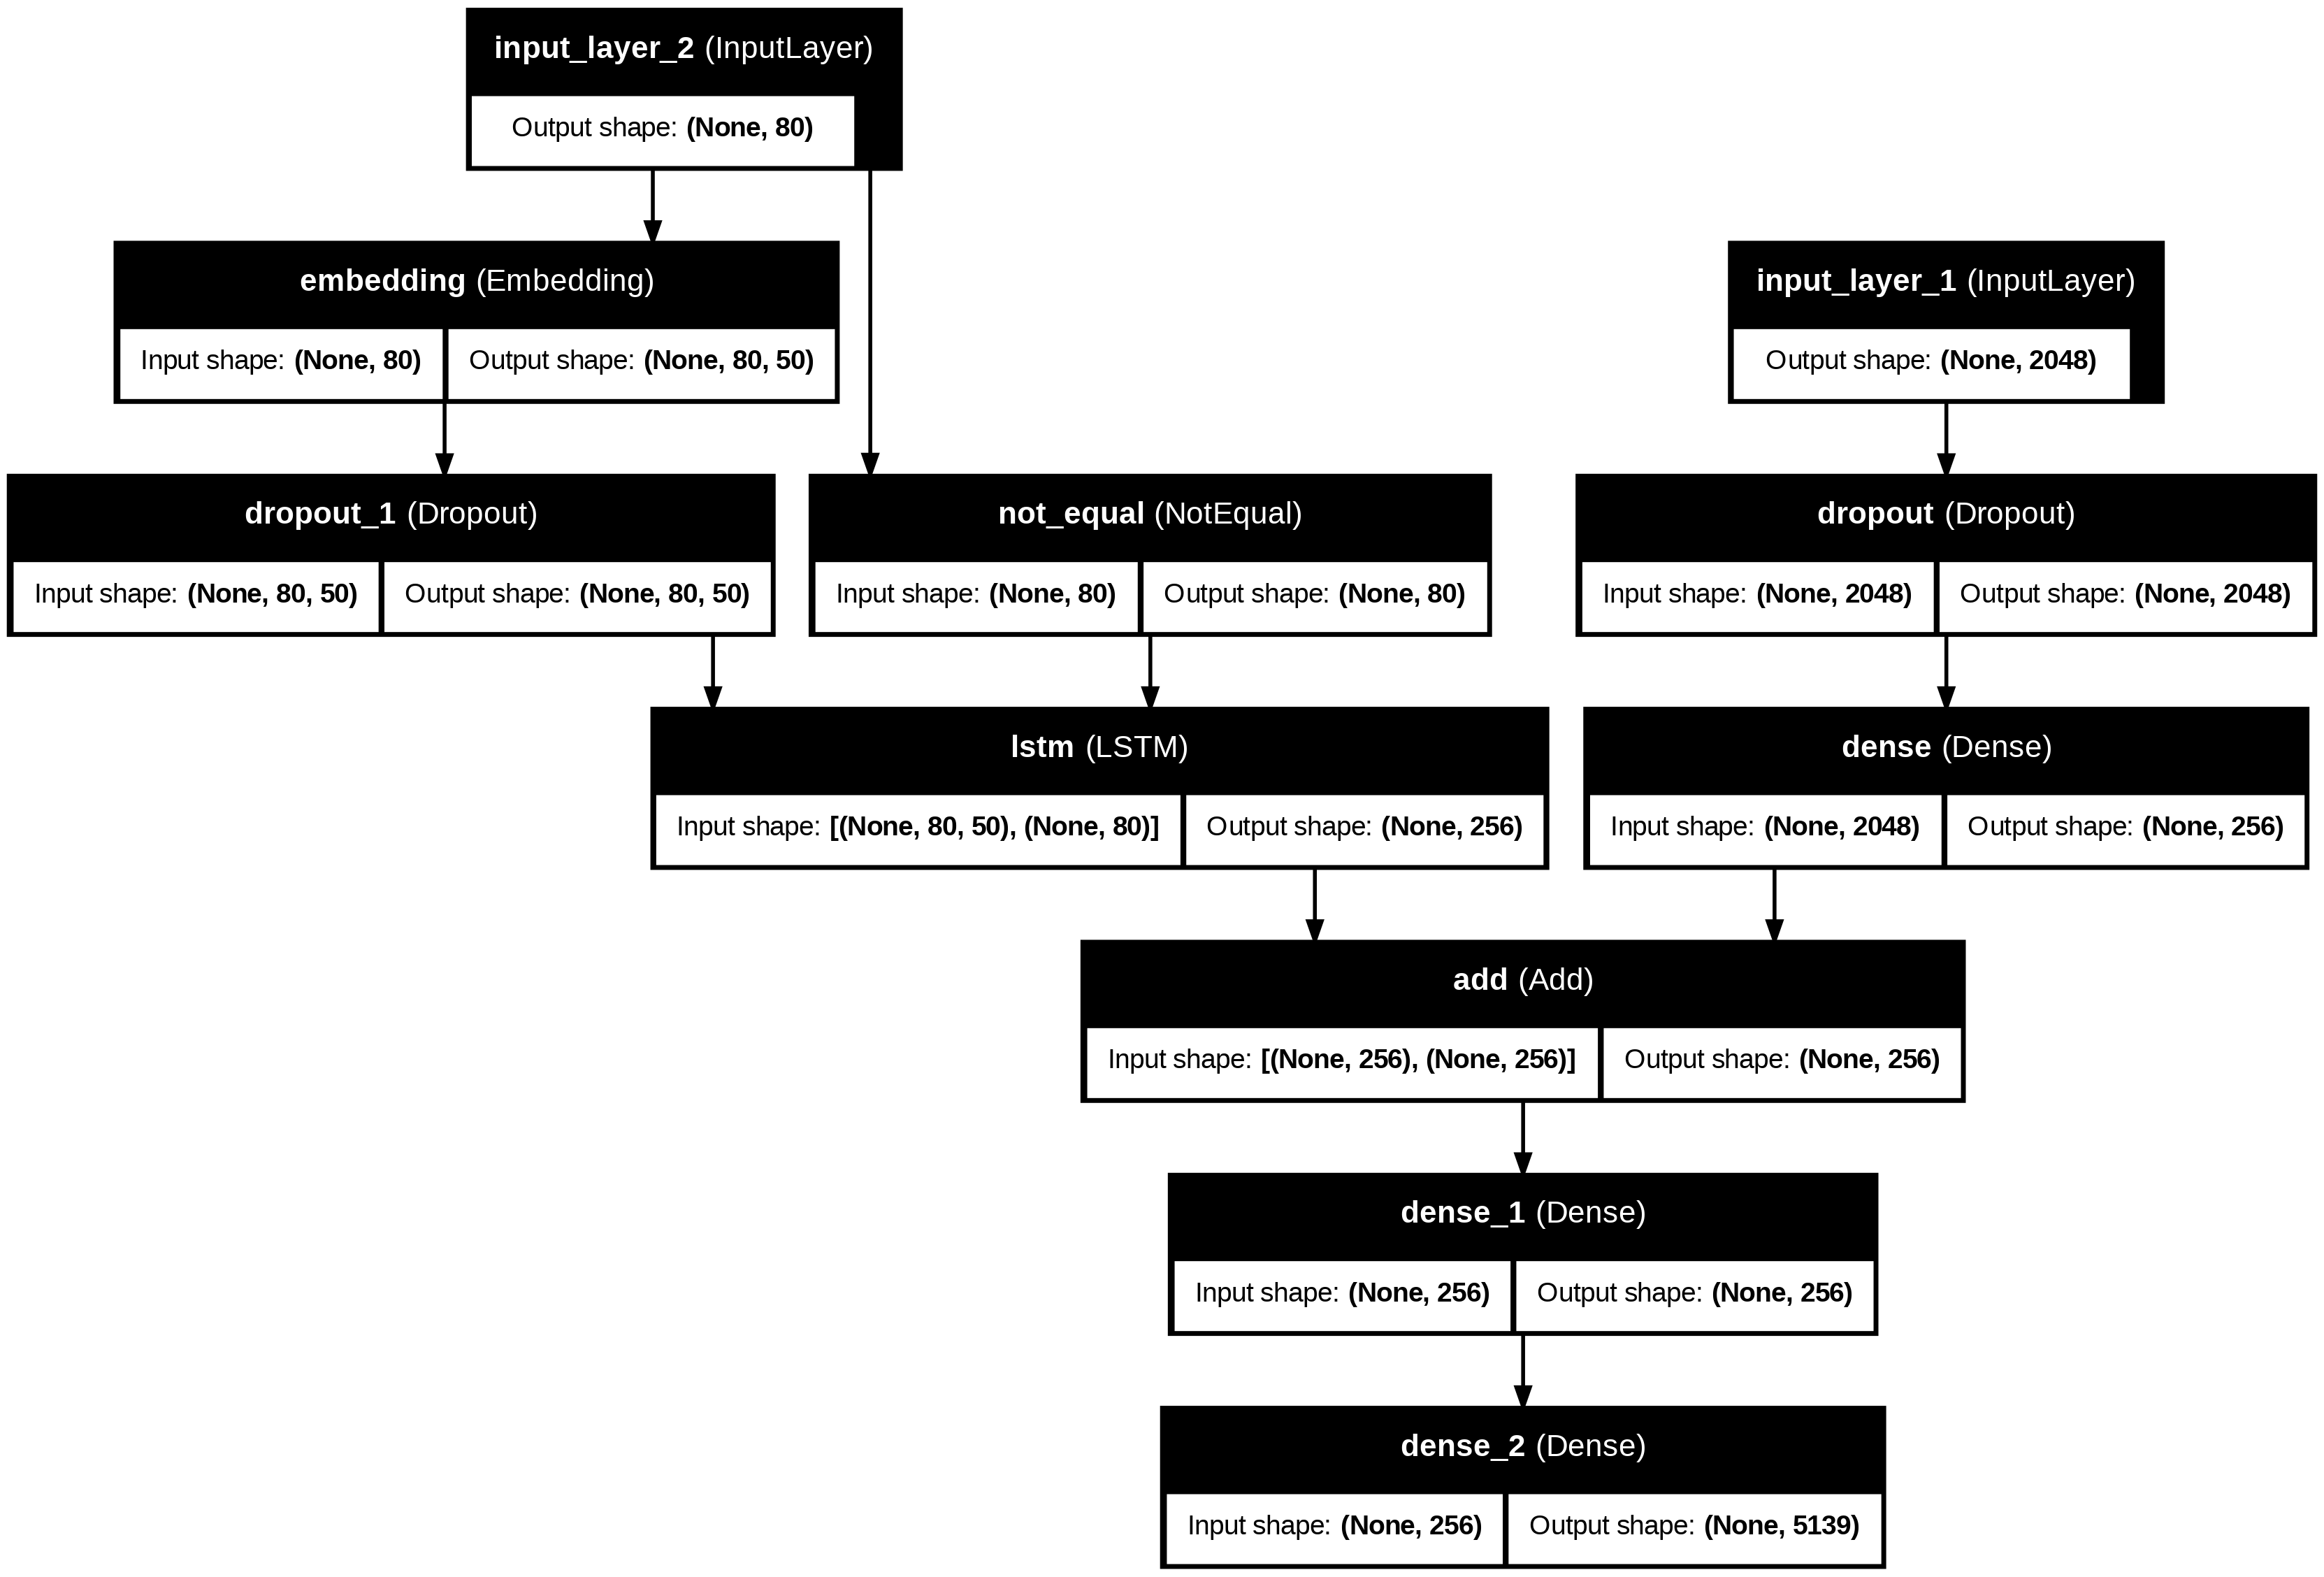

In [39]:
from keras.utils import plot_model

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [40]:
model.layers[2].set_weights([embedding_matrix])
model.layers[2].trainable = False

In [41]:
model.compile(loss="categorical_crossentropy", optimizer="adam")

In [42]:
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

def data_generator (train_content, train_encoding, word_to_index, max_len, batch_size):
    X1, X2, y = [], [], []
    n = 0

    while True:
        for imageID, cap_list in train_content.items():
            n += 1

            image = train_encoding [imageID]

            for caption in cap_list:
                idx_seq = [word_to_index[word] for word in caption.split() if word in word_to_index]

                for i in range (1, len(idx_seq)):
                    xi = idx_seq[0 : i] # The input sequence of words
                    yi = idx_seq[i] # The next word after the above sequence (this is expected to be predicted)

                    # Add a padding of zeros ao lengths of input sequences become equal
                    xi = pad_sequences([xi], maxlen=max_len, value=0, padding='post')[0] # Take the first row only, since this method inputs & returns a 2D array
                    # Convert the expected word to One Hot vector notation
                    yi = to_categorical([yi], num_classes=VOCAB_SIZE)[0]

                    X1.append(image)
                    X2.append(xi)
                    y.append(yi)

                if n==batch_size:
                    # Corrected the return format for multiple inputs: ( (input1, input2), target )
                    yield ((np.array(X1), np.array(X2)), np.array(y))

                    X1, X2, y = [], [], []
                    n=0

TRAINING THE MODEL

In [43]:
epochs = 30
batch_size = 128
steps = len(train_content)//batch_size

In [44]:
import os
from tqdm.keras import TqdmCallback

# Ensure the model_checkpoints directory exists
checkpoint_dir = 'drive/MyDrive/image-caption-generator/model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Load model weights from the last completed epoch (epoch 4) to continue training from epoch 5
initial_epoch = 23
if initial_epoch > 0:
    model_path = os.path.join(checkpoint_dir, f'model_{initial_epoch}.h5')
    if os.path.exists(model_path):
        model.load_weights(model_path)
        print(f"Loaded model weights from {model_path} to continue training from epoch {initial_epoch + 1}")
    else:
        print(f"Warning: Model checkpoint for epoch {initial_epoch} not found at {model_path}. Starting training from epoch 1.")

# Adjust the range to start from the next epoch
for i in range(initial_epoch, epochs):
    # Create an instance of the generator
    generator = data_generator(train_content, train_encoding, word_to_index, max_len, batch_size)
    print(f"\nEpoch {i+1}/{epochs}")
    model.fit(
        generator,
        steps_per_epoch=steps,
        epochs=1, # train for 1 epoch at a time within the loop
        verbose=0, # suppress default Keras verbose output as TqdmCallback will handle it
        callbacks=[TqdmCallback(verbose=1, mininterval=1)] # Add TqdmCallback for progress bar
    )
    model.save(os.path.join(checkpoint_dir, f'model_{i+1}.h5'))

Loaded model weights from drive/MyDrive/image-caption-generator/model_checkpoints/model_23.h5 to continue training from epoch 24

Epoch 24/30


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 25/30


0epoch [00:00, ?epoch/s]

...

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 30/30


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [45]:
model.load_weights('drive/MyDrive/image-caption-generator/model_checkpoints/model_30.h5')

In [46]:
images = 'drive/MyDrive/image-caption-generator/flickr30k_images/'

In [54]:
from pickle import dump, load
with open("encoded_test_features.pkl", "rb") as encoded_pickle:
    encoding_test = load(encoded_pickle)

In [59]:
def greedySearch(photo):
    in_text = 'startseq'
    for i in range(max_len):
        sequence = [word_to_index[w] for w in in_text.split() if w in word_to_index]
        sequence = pad_sequences([sequence], maxlen=max_len, padding = 'post')
        yhat = model.predict([photo,sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = index_to_word[yhat]
        in_text += ' ' + word
        if word == 'endseq':
            break
    final = in_text.split()
    final = final[1:-1]
    final = ' '.join(final)
    return final

In [60]:
z = 0

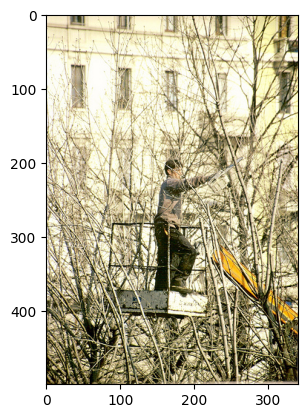

Greedy: a man in a yellow shirt is working on a construction site
121178216


In [89]:
#z = 0
z+=1
pic = list(encoding_test.keys())[z]
image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic+'.jpg')
plt.imshow(x)
plt.show()
print("Greedy:",greedySearch(image))
print(pic)

In [68]:
test_content = {}

for imageID in test_data:
    test_content[imageID] = []
    for caption in content[imageID]:
        # Add a start sequence token in the beginning and an end sequence token at the end
        cap_to_append = caption
        test_content[imageID].append(cap_to_append)

In [69]:
x = 0
pic = list(encoding_test.keys())[x]
test_content[pic]

['the man with pierced ears is wearing glasses and an orange hat ',
 'a man with glasses is wearing a beer can crocheted hat ',
 'a man with gauges and glasses is wearing a blitz hat ',
 'a man in an orange hat starring at something ',
 'a man wears an orange hat and glasses ']

1043819504
Greedy Search Caption: a group of people are standing around a fire

Reference 1: ['a group of people in winter wear such as beanies skiing jackets gloves and backpacks are standing in snow paddles outside a house made of ice blocks while a person in front of the door seems to be leading them ', 'a group of people wearing snowshoes and dressed for winter hiking is standing in front of a building that looks like it s made of blocks of ice ', 'the people are quietly listening while the story of the ice cabin was explained to them ', 'a group of people standing in front of an igloo ', 'several students waiting outside an igloo ']

BLEU-1: 0.822


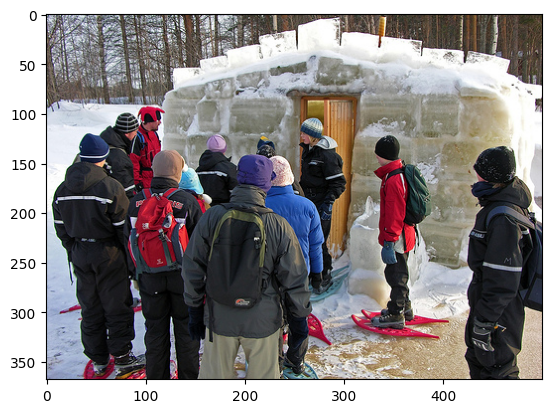

In [91]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

x = 6
pic = list(encoding_test.keys())[x]
test_content[pic]


reference = test_content[pic]
#pic = list(encoding_test.keys())[1]
print(pic)
img = 'twodogs.jpg'
e = encoding_test[pic].reshape(1,2048)
#image = encoding_test[pic].reshape((1,2048))
x=plt.imread(images+pic+'.jpg')
#x=plt.imread(img)
plt.imshow(x)
# plt.show()
caption = greedySearch(e)
print("Greedy Search Caption:",caption)
print()
print('Reference 1:',reference)

print()
print('BLEU-1:', round(sentence_bleu(reference, caption),3))

In [92]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm

def evaluate_model(encoding_test, test_content, max_samples=None):
    """
    Generates captions for test images and computes BLEU-1 to BLEU-4
    against the ground-truth captions.

    encoding_test: dict {image_id: 2048-dim feature vector}
    test_content: dict {image_id: [list of reference caption strings]}
    max_samples: optionally limit to N images (useful for a quick check
                 before running on the full test set, since greedySearch
                 is slow — one word at a time, per image)
    """
    actual, predicted = [], []

    image_ids = list(encoding_test.keys())
    if max_samples:
        image_ids = image_ids[:max_samples]

    for img_id in tqdm(image_ids, desc="Generating captions"):
        # Skip if this image has no reference captions for some reason
        if img_id not in test_content or not test_content[img_id]:
            continue

        image_feature = encoding_test[img_id].reshape((1, 2048))
        generated_caption = greedySearch(image_feature)

        # References: tokenize each ground-truth caption into a list of words
        references = [ref.split() for ref in test_content[img_id]]
        # Hypothesis: tokenize the generated caption
        hypothesis = generated_caption.split()

        actual.append(references)
        predicted.append(hypothesis)

    # Smoothing avoids BLEU scoring 0 when there's no n-gram overlap at all
    smoothie = SmoothingFunction().method4

    bleu1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

    print('\n')
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-3: {bleu3:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

    return {"bleu1": bleu1, "bleu2": bleu2, "bleu3": bleu3, "bleu4": bleu4}, actual, predicted


# Run on a small sample first to sanity-check it works end-to-end
scores, actual, predicted = evaluate_model(encoding_test, test_content, max_samples=100)

# Once confirmed working, run on the full test set (this will be slow —
# greedySearch generates one word at a time per image)
# scores, actual, predicted = evaluate_model(encoding_test, test_content)

Generating captions: 100%|██████████| 100/100 [01:55<00:00,  1.15s/it]

BLEU-1: 0.5693
BLEU-2: 0.3841
BLEU-3: 0.2543
BLEU-4: 0.1677


In [95]:
evaluate_model(encoding_test,test_content)

Generating captions: 100%|██████████| 1000/1000 [20:41<00:00,  1.24s/it]


BLEU-1: 0.5680
BLEU-2: 0.3812
BLEU-3: 0.2535
BLEU-4: 0.1653


({'bleu1': 0.568024721476783,
  'bleu2': 0.3811983180163375,
  'bleu3': 0.25347423654636564,
  'bleu4': 0.1652702749782738},
 [[['the',
    'man',
    'with',
    'pierced',
    'ears',
    'is',
    'wearing',
    'glasses',
    'and',
    'an',
    'orange',
    'hat'],
   ['a',
    'man',
    'with',
    'glasses',
    'is',
    'wearing',
    'a',
    'beer',
    'can',
    'crocheted',
    'hat'],
   ['a',
    'man',
    'with',
    'gauges',
    'and',
    'glasses',
    'is',
    'wearing',
    'a',
    'blitz',
    'hat'],
   ['a', 'man', 'in', 'an', 'orange', 'hat', 'starring', 'at', 'something'],
   ['a', 'man', 'wears', 'an', 'orange', 'hat', 'and', 'glasses']],
  [['a',
    'black',
    'and',
    'white',
    'dog',
    'is',
    'running',
    'in',
    'a',
    'grassy',
    'garden',
    'surrounded',
    'by',
    'a',
    'white',
    'fence'],
   ['a',
    'boston',
    'terrier',
    'is',
    'running',
    'on',
    'lush',
    'green',
    'grass',
    'in',
    